https://view12350.tistory.com/1

In [406]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
# Google Drive Mount
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [407]:
import os

# File paths
train_file = '/content/drive/My Drive/Colab Notebooks/data/house_price_prediction/train.csv'
test_file = '/content/drive/My Drive/Colab Notebooks/data/house_price_prediction/test.csv'

# Check if files exist
if os.path.exists(train_file) and os.path.exists(test_file):
    print("Train and Test files found, loading data...")
    train_data = pd.read_csv(train_file)
    test_data = pd.read_csv(test_file)

    # Display head of both datasets
    print("Train data head:")
    print(train_data.head())
    print("\nTest data head:")
    print(test_data.head())
else:
    print("One or both files are missing. Please check the paths.")

# Ensure DataFrame format
print("\nData types:")
print(type(train_data), type(test_data))

Train and Test files found, loading data...
Train data head:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSol

In [408]:
# 데이터 타입을 확인
column_types = train_data.dtypes

# 숫자형 열 추출
numerical_columns = column_types[column_types.apply(lambda x: pd.api.types.is_numeric_dtype(x))].index.tolist()

# 범주형 열 추출
categorical_columns = column_types[column_types.apply(lambda x: pd.api.types.is_categorical_dtype(x) or pd.api.types.is_object_dtype(x))].index.tolist()

# 중복되는 열 확인
overlapping_columns = set(numerical_columns) & set(categorical_columns)

if overlapping_columns:
    print(f"중복되는 열이 있습니다: {overlapping_columns}")
else:
    print("중복되는 열이 없습니다.")


print("숫자형 열:", numerical_columns)
print("범주형 열:", categorical_columns)

중복되는 열이 없습니다.
숫자형 열: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
범주형 열: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'Garage

<ipython-input-408-77563bb62531>:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categorical_columns = column_types[column_types.apply(lambda x: pd.api.types.is_categorical_dtype(x) or pd.api.types.is_object_dtype(x))].index.tolist()


In [409]:
# 삭제할 숫자형 열
num_cols_to_drop = ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallCond', 'MasVnrArea',
 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', '2ndFlrSF', 'LowQualFinSF',
 'BsmtFullBath', 'BsmtHalfBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
 'Fireplaces', 'GarageYrBlt', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
 '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

# 남길 숫자형 열
num_cols_to_keep = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
                    'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt',
                    'YearRemodAdd']

print(len(num_cols_to_drop))
print(len(num_cols_to_keep))

# 삭제할 범주형 열
cat_cols_to_drop = ['MSZoning', 'Alley', 'PavedDrive', 'SaleType', 'SaleCondition',
                    'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
                    'LandSlope', 'Condition1', 'Condition2', 'RoofMatl', 'Exterior1st',
                    'Exterior2nd', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical',
                    'Functional', 'GarageQual', 'GarageCond', 'MiscFeature']

# 남길 범주형 열
cat_cols_to_keep = ['Neighborhood', 'BldgType', 'HouseStyle', 'RoofStyle', 'MasVnrType',
                    'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
                    'BsmtExposure', 'BsmtFinType1', 'HeatingQC', 'KitchenQual',
                    'FireplaceQu', 'GarageType', 'GarageFinish', 'PoolQC', 'Fence']

#주석 달아서 제거
print(len(cat_cols_to_drop))
print(len(cat_cols_to_keep))

# train 데이터에서 필요한 열만 선택
train_cols_to_keep = num_cols_to_keep + cat_cols_to_keep
train_data_filtered = train_data[train_cols_to_keep]

# test 데이터에서 필요한 열만 선택 (SalePrice는 test 데이터에 없으므로 제외)
test_cols_to_keep = [col for col in train_cols_to_keep if col != 'SalePrice']
test_data_filtered = test_data[test_cols_to_keep]

# 이것도 주석 달아서 마지막에 제거

print(f"Train 데이터 열 개수: {len(train_data_filtered.columns)}")
print(f"Test 데이터 열 개수: {len(test_data_filtered.columns)}")

# 결과 확인
def print_columns_in_batches(columns, batch_size=10):
    for i in range(0, len(columns), batch_size):
        print(columns[i:i + batch_size])

print(f"Train 데이터 열 개수: {len(train_data_filtered.columns)}")
print("Train 데이터 열 목록:")
print_columns_in_batches(train_data_filtered.columns.tolist())

print(f"\nTest 데이터 열 개수: {len(test_data_filtered.columns)}")
print("Test 데이터 열 목록:")
print_columns_in_batches(test_data_filtered.columns.tolist())




27
11
24
19
Train 데이터 열 개수: 30
Test 데이터 열 개수: 29
Train 데이터 열 개수: 30
Train 데이터 열 목록:
['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt']
['YearRemodAdd', 'Neighborhood', 'BldgType', 'HouseStyle', 'RoofStyle', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual']
['BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageType', 'GarageFinish', 'PoolQC', 'Fence']

Test 데이터 열 개수: 29
Test 데이터 열 목록:
['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']
['Neighborhood', 'BldgType', 'HouseStyle', 'RoofStyle', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond']
['BsmtExposure', 'BsmtFinType1', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageType', 'GarageFinish', 'PoolQC', 'Fence']


In [410]:
from sklearn.impute import SimpleImputer

# Define imputers
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='constant', fill_value='Missing')

# Separate numerical and categorical columns
cat_cols = cat_cols_to_keep
num_cols = [col for col in num_cols_to_keep if col != 'SalePrice']

# Ensure categorical columns are of type 'str' to avoid casting issues
train_data_filtered[cat_cols] = train_data_filtered[cat_cols].astype(str)
test_data_filtered[cat_cols] = test_data_filtered[cat_cols].astype(str)

# Impute numerical columns
train_data_filtered.loc[:, num_cols] = num_imputer.fit_transform(train_data_filtered[num_cols])
test_data_filtered.loc[:, num_cols] = num_imputer.transform(test_data_filtered[num_cols])

# Impute categorical columns
train_data_filtered.loc[:, cat_cols] = cat_imputer.fit_transform(train_data_filtered[cat_cols])
test_data_filtered.loc[:, cat_cols] = cat_imputer.transform(test_data_filtered[cat_cols])

print("Missing values successfully imputed.")


Missing values successfully imputed.


<ipython-input-410-4ffb93564026>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data_filtered[cat_cols] = train_data_filtered[cat_cols].astype(str)
<ipython-input-410-4ffb93564026>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data_filtered[cat_cols] = test_data_filtered[cat_cols].astype(str)


In [411]:
from sklearn.preprocessing import LabelEncoder  # LabelEncoder 임포트

# Label Encoding for categorical features
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(train_data_filtered[col])
    label_encoders[col] = le
    test_data_filtered[col] = test_data_filtered[col].apply(lambda x: x if x in le.classes_ else 'Missing')
    le.classes_ = np.append(le.classes_, 'Missing')
    train_data_filtered[col] = le.transform(train_data_filtered[col])
    test_data_filtered[col] = le.transform(test_data_filtered[col])

<ipython-input-411-49ab82da41b0>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data_filtered[col] = test_data_filtered[col].apply(lambda x: x if x in le.classes_ else 'Missing')
<ipython-input-411-49ab82da41b0>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data_filtered[col] = le.transform(train_data_filtered[col])
<ipython-input-411-49ab82da41b0>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

In [412]:
from collections import Counter  # Counter 임포트
# SalePrice를 기준으로 이진 라벨링 수행
threshold = train_data_filtered['SalePrice'].median()
y_train_binary = (train_data_filtered['SalePrice'] > threshold).astype(int)  # 중간값 초과 -> 1, 이하 -> 0
#y_test_binary = (test_data_filtered['SalePrice'] > threshold).astype(int)  # SalePrice는 실제로 없으므로 이 부분은 제거됨


X_train = train_data_filtered.drop(columns=['SalePrice'])
X_test = test_data_filtered

print(f"SalePrice Median: {threshold}")
print("Class distribution before SMOTE:", Counter(y_train_binary))

SalePrice Median: 163000.0
Class distribution before SMOTE: Counter({0: 732, 1: 728})


In [413]:
from sklearn.preprocessing import StandardScaler, Normalizer, RobustScaler
# 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE 적용
min_class_size = min(Counter(y_train_binary).values())
k_neighbors = max(1, min(5, min_class_size - 1))  # 최소 1 이상
print(f"Using k_neighbors = {k_neighbors}")

try:
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_binary)
    print("SMOTE successfully applied.")
except ValueError as e:
    print("SMOTE failed with the following error:")
    print(e)

Using k_neighbors = 5
SMOTE successfully applied.


In [414]:
# SMOTE 후 클래스 분포 확인
if 'X_train_smote' in locals():
    print("SMOTE applied class distribution:", Counter(y_train_smote))
else:
    print("SMOTE could not be applied due to the error above.")

SMOTE applied class distribution: Counter({1: 732, 0: 732})


In [415]:
# # 1. SMOTE 적용하지 않은 경우
# rf_no_smote = RandomForestClassifier(random_state=42)
# rf_no_smote.fit(X_train_scaled, y_train)

# # Train accuracy
# train_pred_no_smote = rf_no_smote.predict(X_train_scaled)
# print("SMOTE 미적용 Train Accuracy:", accuracy_score(y_train, train_pred_no_smote))

# # Test accuracy
# y_pred_no_smote = rf_no_smote.predict(X_test_scaled)
# print("SMOTE 미적용 Test Accuracy:", accuracy_score(y_train, y_pred_no_smote))
# print(classification_report(y_train, y_pred_no_smote))

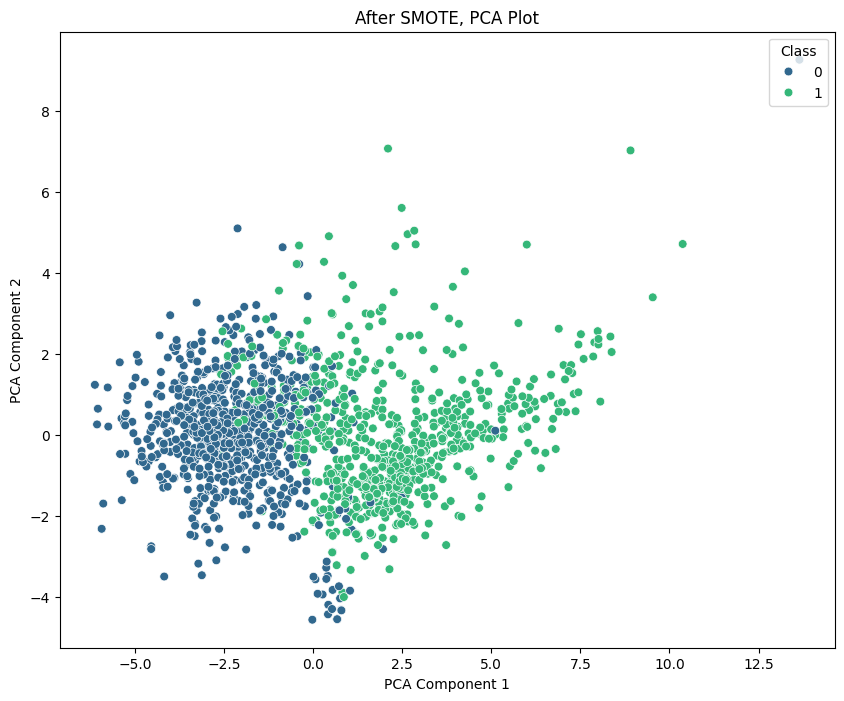

In [416]:
# PCA로 2D 변환
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_smote)
X_test_pca = pca.transform(X_test_scaled)

# 데이터 분포 시각화
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    hue=y_train_smote,
    palette="viridis",
    s=40
)
plt.title("After SMOTE, PCA Plot")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Class", loc="upper right")
plt.show()

In [417]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundary(X, y, model, model_name, title):
    X1, X2 = X[:, 0], X[:, 1]
    x1_min, x1_max = X1.min() - 1, X1.max() + 1
    x2_min, x2_max = X2.min() - 1, X2.max() + 1

    # 그리드 생성
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.1),
                           np.arange(x2_min, x2_max, 0.1))
    Z = model.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)

    # 결정 경계와 데이터 시각화
    plt.figure(figsize=(10, 8))
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=ListedColormap(['lightblue', 'lightcoral']))
    plt.scatter(X1, X2, c=y, cmap=ListedColormap(['blue', 'red']), edgecolor='k')
    plt.title(title)
    plt.xlabel(f"{model_name} - PCA Component 1")
    plt.ylabel(f"{model_name} - PCA Component 2")
    plt.show()


Perceptron train_accuracy :  0.8975409836065574


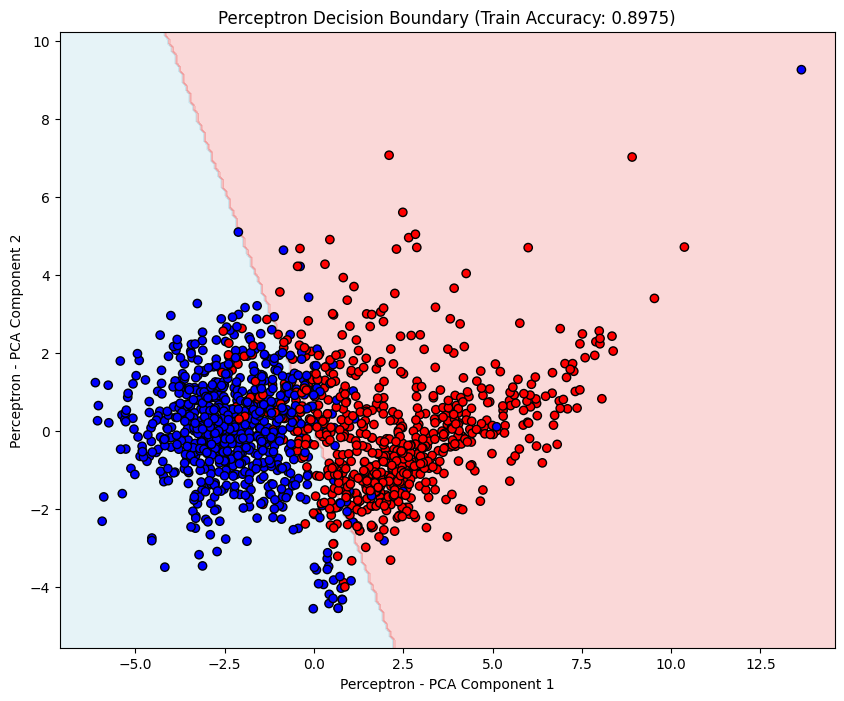

In [418]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# Perceptron 모델 학습
perceptron = Perceptron(max_iter=1000, tol=1e-3, random_state=42)
perceptron.fit(X_train_pca, y_train_smote)

# 정확도 계산
y_pred_train = perceptron.predict(X_train_pca)
train_accuracy = accuracy_score(y_train_smote, y_pred_train)
print("Perceptron train_accuracy : ", train_accuracy)

# 결정 경계 시각화
plot_decision_boundary(X_train_pca, y_train_smote, perceptron, "Perceptron",
                       f"Perceptron Decision Boundary (Train Accuracy: {train_accuracy:.4f})")


In [419]:
class AdalineGD(object):
    """ADAptive LInear NEuron classifier."""
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.cost_ = []

        for i in range(self.n_iter):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            errors = (y - output)
            self.w_[1:] += self.eta * X.T.dot(errors)
            self.w_[0] += self.eta * errors.sum()
            cost = (errors**2).sum() / 2.0
            self.cost_.append(cost)
        return self

    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activation(self, X):
        return X

    def predict(self, X):
        return np.where(self.activation(self.net_input(X)) >= 0.0, 1, -1)


adaline_gd train_accuracy :  0.06352459016393443


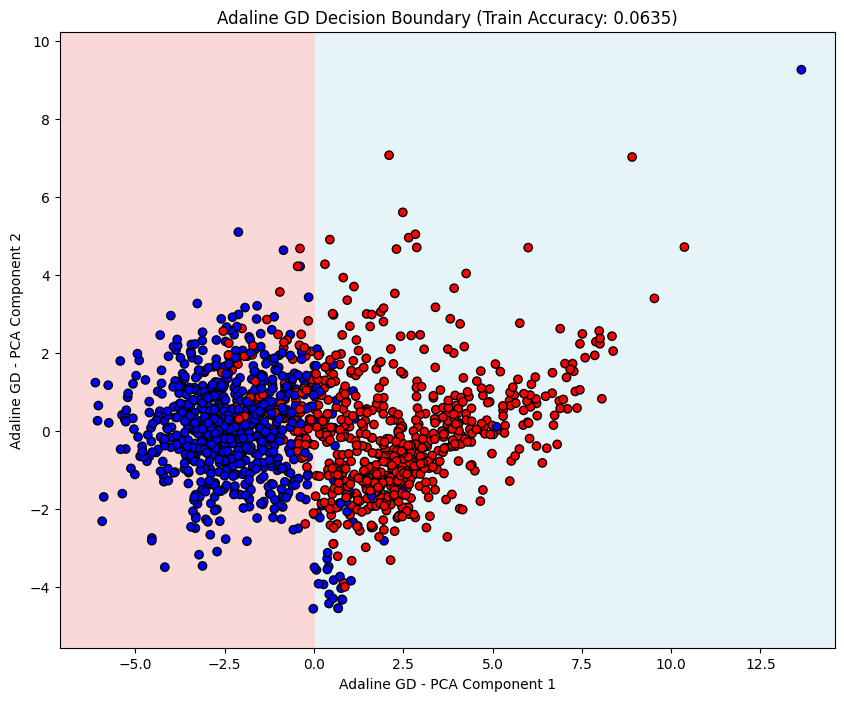

In [420]:
adaline_gd = AdalineGD(eta=0.01, n_iter=50, random_state=42)
adaline_gd.fit(X_train_pca, y_train_smote)

# 정확도 계산
y_pred_train = adaline_gd.predict(X_train_pca)
train_accuracy = accuracy_score(y_train_smote, y_pred_train)

print("adaline_gd train_accuracy : ", train_accuracy)
# 결정 경계 시각화
plot_decision_boundary(X_train_pca, y_train_smote, adaline_gd, "Adaline GD",
                       f"Adaline GD Decision Boundary (Train Accuracy: {train_accuracy:.4f})")


AdalineSGD Train Accuracy: 0.9064207650273224


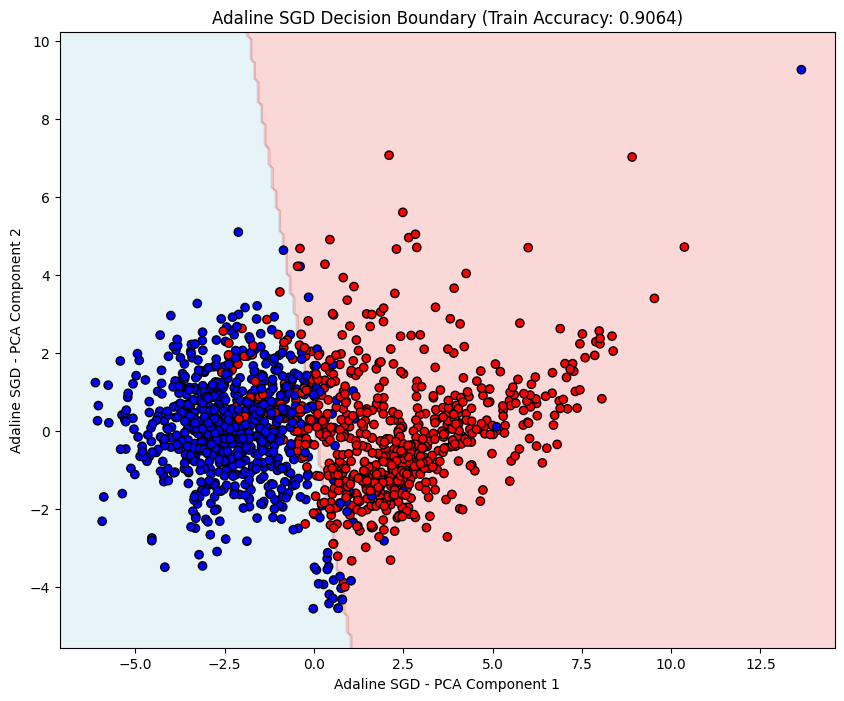

In [421]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

# AdalineSGD 모델 (SGDClassifier with squared_error for Adaline behavior)
adaline_sgd = SGDClassifier(loss="squared_error", learning_rate="constant", eta0=0.01,
                            max_iter=1000, tol=1e-3, random_state=42)
adaline_sgd.fit(X_train_pca, y_train_smote)  # PCA 데이터를 학습에 사용

# 예측 및 정확도
y_pred_train = adaline_sgd.predict(X_train_pca)
train_accuracy = accuracy_score(y_train_smote, y_pred_train)

print("AdalineSGD Train Accuracy:", train_accuracy)

# 결정 경계 시각화
plot_decision_boundary(X_train_pca, y_train_smote, adaline_sgd, "Adaline SGD",
                       f"Adaline SGD Decision Boundary (Train Accuracy: {train_accuracy:.4f})")


knn train_accuracy :  0.9221311475409836


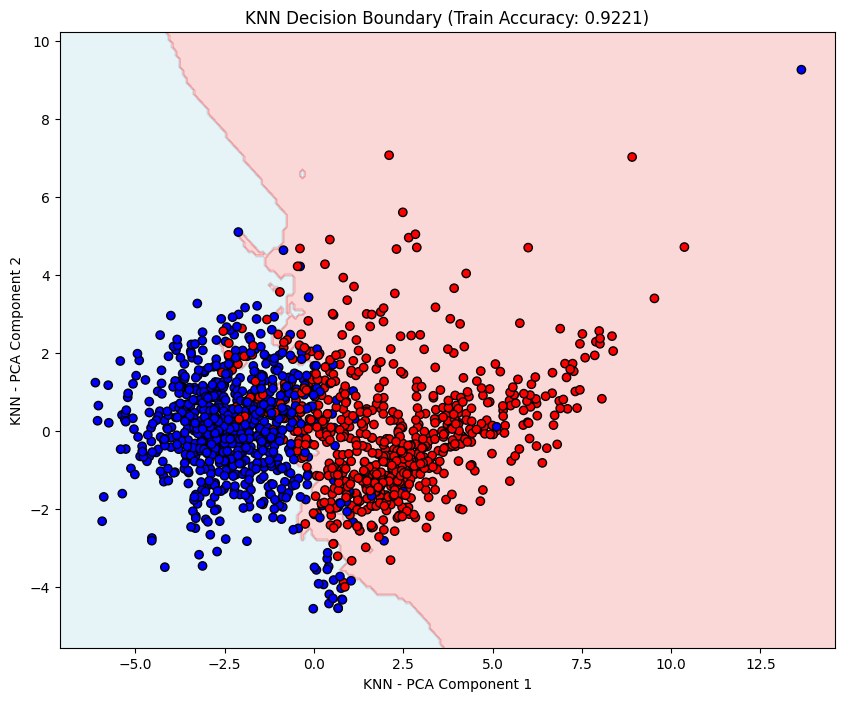

In [422]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train_smote)

# 정확도 계산
y_pred_train = knn.predict(X_train_pca)
train_accuracy = accuracy_score(y_train_smote, y_pred_train)

print("knn train_accuracy : ", train_accuracy)

# 결정 경계 시각화
plot_decision_boundary(X_train_pca, y_train_smote, knn, "KNN",
                       f"KNN Decision Boundary (Train Accuracy: {train_accuracy:.4f})")


decision_tree train_accuracy :  0.9993169398907104


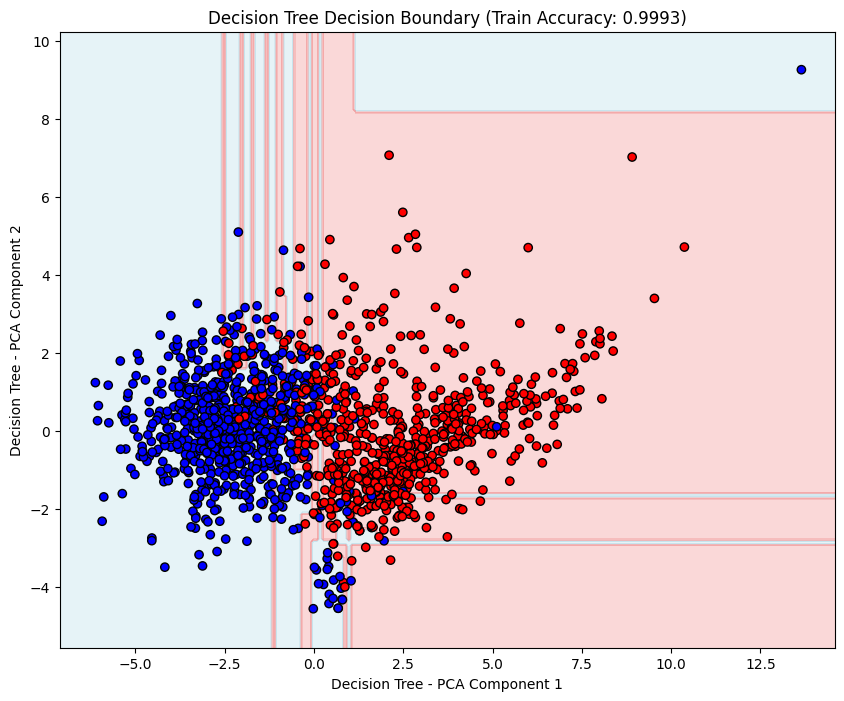

In [423]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_pca, y_train_smote)

# 정확도 계산
y_pred_train = dt.predict(X_train_pca)
train_accuracy = accuracy_score(y_train_smote, y_pred_train)

print("decision_tree train_accuracy : ", train_accuracy)

# 결정 경계 시각화
plot_decision_boundary(X_train_pca, y_train_smote, dt, "Decision Tree",
                       f"Decision Tree Decision Boundary (Train Accuracy: {train_accuracy:.4f})")


SVM train_accuracy :  0.9105191256830601


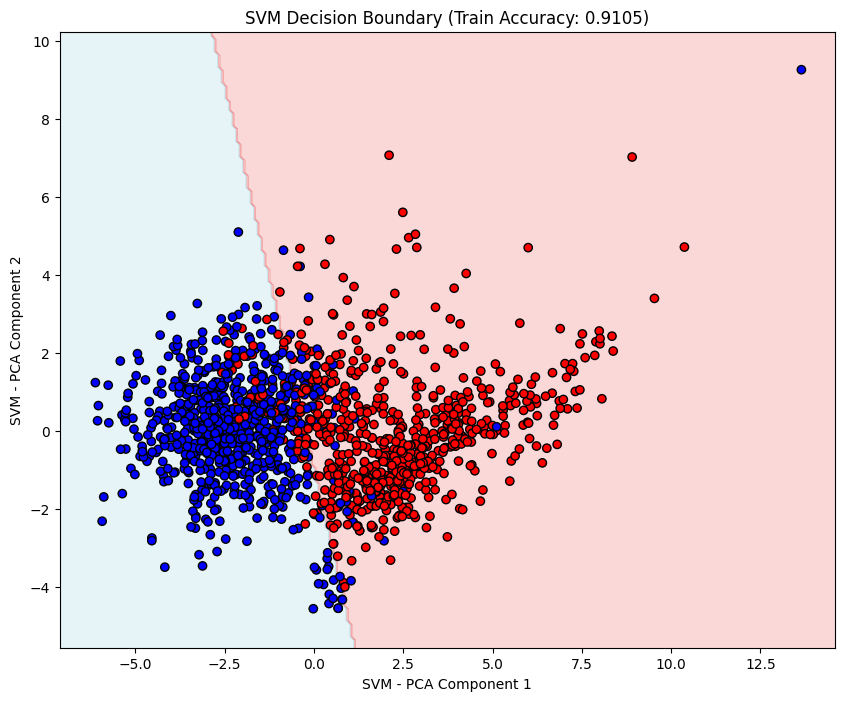

In [424]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train_pca, y_train_smote)

# 정확도 계산
y_pred_train = svm.predict(X_train_pca)
train_accuracy = accuracy_score(y_train_smote, y_pred_train)

print("SVM train_accuracy : ", train_accuracy)
\
# 결정 경계 시각화
plot_decision_boundary(X_train_pca, y_train_smote, svm, "SVM",
                       f"SVM Decision Boundary (Train Accuracy: {train_accuracy:.4f})")


Decision Tree Cross-Validation Accuracy: 0.8688


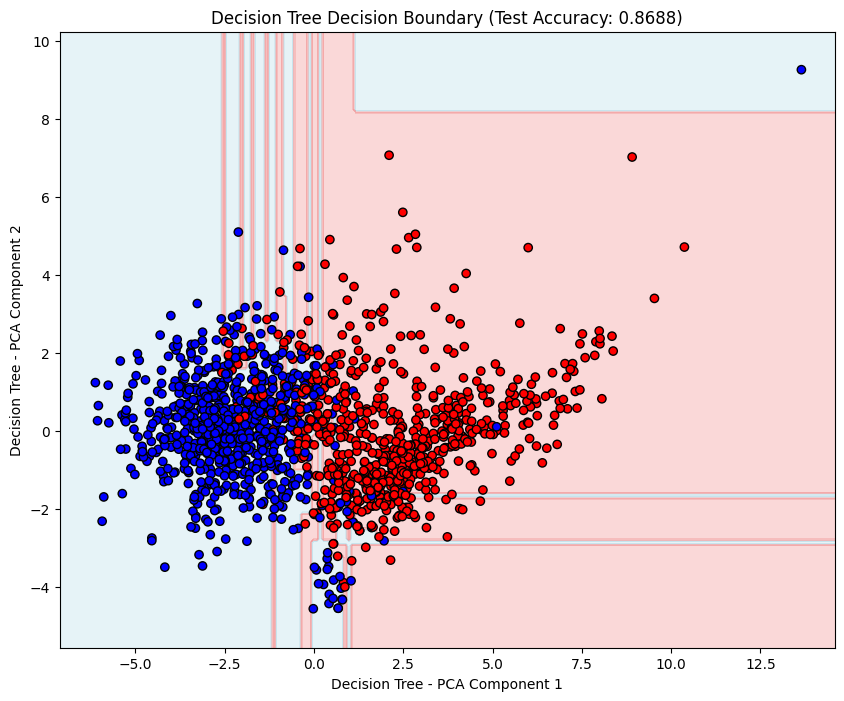

In [425]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Decision Tree 모델 생성
dt = DecisionTreeClassifier(random_state=42)

# 교차 검증을 통한 정확도 계산
cv_scores = cross_val_score(dt, X_train_pca, y_train_smote, cv=5)
print(f"Decision Tree Cross-Validation Accuracy: {np.mean(cv_scores):.4f}")

# 모델 학습
dt.fit(X_train_pca, y_train_smote)

# 결정 경계 시각화
plot_decision_boundary(X_train_pca, y_train_smote, dt, "Decision Tree",
                       f"Decision Tree Decision Boundary (Test Accuracy: {np.mean(cv_scores):.4f})")


KNN Cross-Validation Accuracy: 0.8928


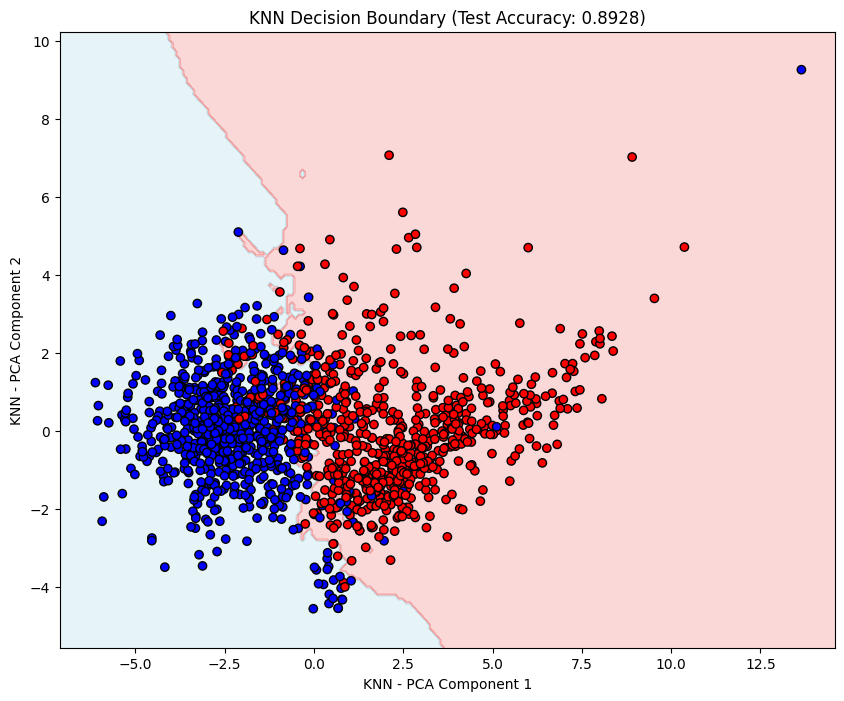

In [426]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# KNN 모델 생성
knn = KNeighborsClassifier(n_neighbors=5)

# 교차 검증을 통한 정확도 계산
cv_scores = cross_val_score(knn, X_train_pca, y_train_smote, cv=5)
print(f"KNN Cross-Validation Accuracy: {np.mean(cv_scores):.4f}")

# 모델 학습
knn.fit(X_train_pca, y_train_smote)

# 결정 경계 시각화
plot_decision_boundary(X_train_pca, y_train_smote, knn, "KNN",
                       f"KNN Decision Boundary (Test Accuracy: {np.mean(cv_scores):.4f})")


SVM Cross-Validation Accuracy: 0.9099


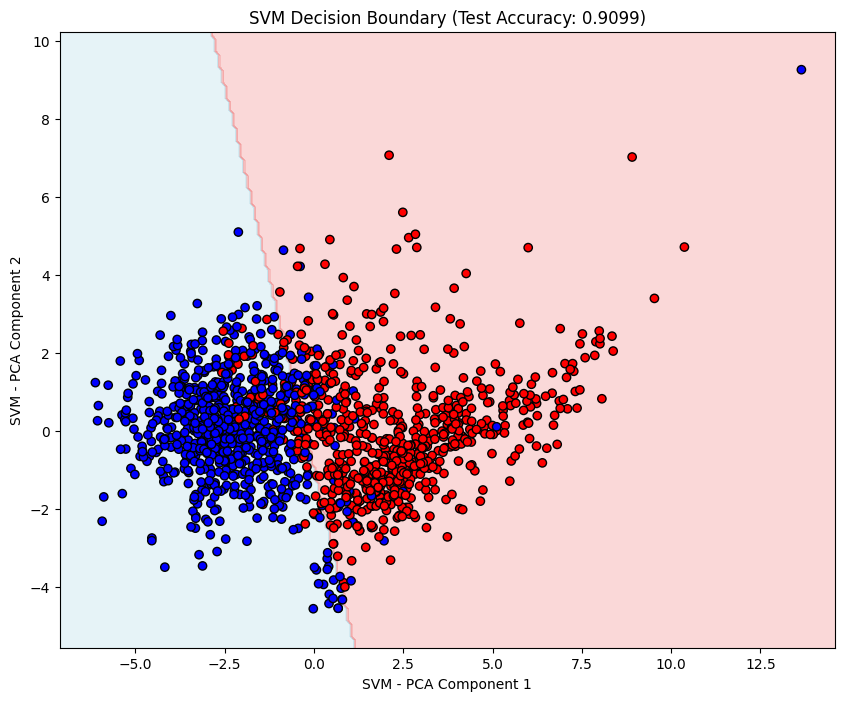

In [427]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import numpy as np

# SVM 모델 생성
svm = SVC(kernel='linear', random_state=42)

# 교차 검증을 통한 정확도 계산
cv_scores = cross_val_score(svm, X_train_pca, y_train_smote, cv=5)
print(f"SVM Cross-Validation Accuracy: {np.mean(cv_scores):.4f}")

# 모델 학습
svm.fit(X_train_pca, y_train_smote)

# 결정 경계 시각화
plot_decision_boundary(X_train_pca, y_train_smote, svm, "SVM",
                       f"SVM Decision Boundary (Test Accuracy: {np.mean(cv_scores):.4f})")


Adaline SGD Cross-Validation Accuracy: 0.8873


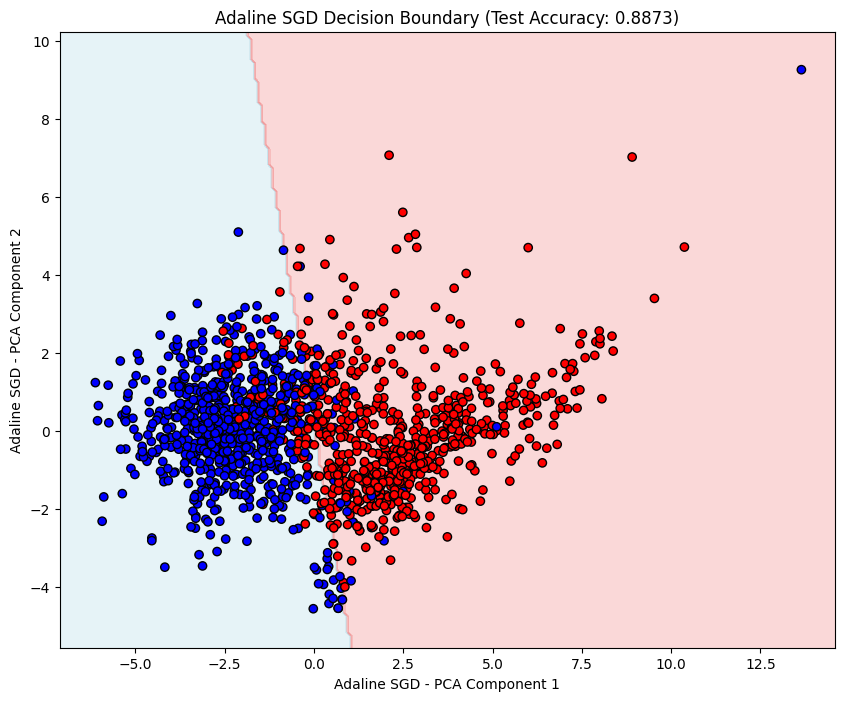

In [428]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Adaline SGD 모델 생성
adaline_sgd = SGDClassifier(loss="squared_error", learning_rate="constant", eta0=0.01,
                            max_iter=1000, tol=1e-3, random_state=42)

# 교차 검증을 통한 정확도 계산
cv_scores = cross_val_score(adaline_sgd, X_train_pca, y_train_smote, cv=5)
print(f"Adaline SGD Cross-Validation Accuracy: {np.mean(cv_scores):.4f}")

# 모델 학습
adaline_sgd.fit(X_train_pca, y_train_smote)

# 결정 경계 시각화
plot_decision_boundary(X_train_pca, y_train_smote, adaline_sgd, "Adaline SGD",
                       f"Adaline SGD Decision Boundary (Test Accuracy: {np.mean(cv_scores):.4f})")


#회귀모델 작성

In [445]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Ensure X_train and y_train are aligned
# `train_data_filtered`에서 `SalePrice`를 기준으로 나눈 후 `drop(columns=['SalePrice'])`로 정의
X_train = train_data_filtered.drop(columns=['SalePrice'])
y_train = train_data_filtered['SalePrice']

# Train:Validation 분할
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# X_test에 X_train과 동일한 피처만 남기기
X_test = test_data_filtered[X_train.columns]

# 스케일링 (Train 데이터로 학습한 스케일러 사용)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Train 데이터로 fit
X_valid_scaled = scaler.transform(X_valid)      # Validation 데이터 transform
X_test_scaled = scaler.transform(X_test)        # Test 데이터 transform

# 데이터 Shape 확인
print("Train shape:", X_train_scaled.shape)
print("Validation shape:", X_valid_scaled.shape)
print("Test shape:", X_test_scaled.shape)

# Linear Regression 모델 학습 및 평가
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Train 및 Validation 정확도 평가
train_accuracy = lr.score(X_train_scaled, y_train)
valid_accuracy = lr.score(X_valid_scaled, y_valid)

print(f"Linear Regression - Train Accuracy: {train_accuracy:.4f}")
print(f"Linear Regression - Validation Accuracy: {valid_accuracy:.4f}")

# Test 데이터 예측 (y_test가 없으므로 예측값만 생성)
test_predictions = lr.predict(X_test_scaled)
print("Test Predictions (first 10 values):", test_predictions[:10])


Train shape: (1168, 29)
Validation shape: (292, 29)
Test shape: (1459, 29)
Linear Regression - Train Accuracy: 0.8161
Linear Regression - Validation Accuracy: 0.8294
Test Predictions (first 10 values): [ 95097.27875525 161613.90096724 171130.66831253 188483.36420351
 199455.02474123 173876.26964431 175805.62906296 172968.85069614
 210982.1439034  112646.02965727]


In [459]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 데이터 분할
X_train = train_data_filtered.drop(columns=['SalePrice'])
y_train = train_data_filtered['SalePrice']

X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
X_test = test_data_filtered[X_train.columns]

# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
train_accuracy_lr = r2_score(y_train, lr.predict(X_train_scaled))
valid_accuracy_lr = r2_score(y_valid, lr.predict(X_valid_scaled))

print(f"Linear Regression - Train Accuracy: {train_accuracy_lr:.4f}")
print(f"Linear Regression - Validation Accuracy: {valid_accuracy_lr:.4f}")

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
train_accuracy_ridge = r2_score(y_train, ridge.predict(X_train_scaled))
valid_accuracy_ridge = r2_score(y_valid, ridge.predict(X_valid_scaled))

print(f"Ridge Regression - Train Accuracy: {train_accuracy_ridge:.4f}")
print(f"Ridge Regression - Validation Accuracy: {valid_accuracy_ridge:.4f}")

# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
train_accuracy_lasso = r2_score(y_train, lasso.predict(X_train_scaled))
valid_accuracy_lasso = r2_score(y_valid, lasso.predict(X_valid_scaled))

print(f"Lasso Regression - Train Accuracy: {train_accuracy_lasso:.4f}")
print(f"Lasso Regression - Validation Accuracy: {valid_accuracy_lasso:.4f}")

# Polynomial Regression with Ridge Regularization
poly_pipeline = Pipeline([
    ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("ridge_regression", Ridge(alpha=0.1))
])
poly_pipeline.fit(X_train_scaled, y_train)
train_accuracy_poly = r2_score(y_train, poly_pipeline.predict(X_train_scaled))
valid_accuracy_poly = r2_score(y_valid, poly_pipeline.predict(X_valid_scaled))

print(f"Polynomial Regression - Train Accuracy: {train_accuracy_poly:.4f}")
print(f"Polynomial Regression - Validation Accuracy: {valid_accuracy_poly:.4f}")

# Test 데이터 예측 (Polynomial Regression)
test_predictions_lr = lr.predict(X_test_scaled)
test_predictions_ridge = ridge.predict(X_test_scaled)
test_predictions_lasso = lasso.predict(X_test_scaled)
test_predictions_poly = poly_pipeline.predict(X_test_scaled)

print("\nTest Predictions (first 10 values):")
print(f"Linear Regression: {test_predictions_lr[:10]}")
print(f"Ridge Regression: {test_predictions_ridge[:10]}")
print(f"Lasso Regression: {test_predictions_lasso[:10]}")
print(f"Polynomial Regression: {test_predictions_poly[:10]}")


Linear Regression - Train Accuracy: 0.8161
Linear Regression - Validation Accuracy: 0.8294
Ridge Regression - Train Accuracy: 0.8161
Ridge Regression - Validation Accuracy: 0.8294
Lasso Regression - Train Accuracy: 0.8161
Lasso Regression - Validation Accuracy: 0.8294
Polynomial Regression - Train Accuracy: 0.9436
Polynomial Regression - Validation Accuracy: 0.7635

Test Predictions (first 10 values):
Linear Regression: [ 95097.27875525 161613.90096724 171130.66831253 188483.36420351
 199455.02474123 173876.26964431 175805.62906296 172968.85069614
 210982.1439034  112646.02965727]
Ridge Regression: [ 95220.8819517  161588.32497512 171112.46824556 188519.65561142
 199467.39236735 173867.55745251 175833.64317802 172998.27205679
 210882.84291516 112637.00016924]
Lasso Regression: [ 95099.87691619 161613.73047746 171130.45335273 188484.01366057
 199455.25242635 173875.95600468 175805.65693727 172968.5930312
 210980.68312409 112645.41267194]
Polynomial Regression: [127076.96001997 157238.22

In [463]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_samples, silhouette_score
from matplotlib import cm
import matplotlib.pyplot as plt
import numpy as np

# DBSCAN 파라미터 설정 및 모델 학습
eps_value = 0.5  # 필요에 따라 조정
min_samples_value = 5  # 필요에 따라 조정

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
y_dbscan = dbscan.fit_predict(X_train_scaled)

# 노이즈 제외한 클러스터 수 계산
cluster_labels = np.unique(y_dbscan)
n_clusters = len(cluster_labels) - (1 if -1 in cluster_labels else 0)  # 노이즈 (-1) 제외

# 실루엣 점수 계산
if n_clusters > 1:  # Silhouette score는 클러스터가 2개 이상일 때 정의됨
    silhouette_avg = silhouette_score(X_train_scaled, y_dbscan)
    silhouette_vals = silhouette_samples(X_train_scaled, y_dbscan)

    # 실루엣 플롯
    plt.figure(figsize=(10, 7))
    y_ax_lower, y_ax_upper = 0, 0
    yticks = []

    for i, c in enumerate(cluster_labels):
        if c == -1:  # 노이즈 클러스터 제외
            continue

        c_silhouette_vals = silhouette_vals[y_dbscan == c]
        c_silhouette_vals.sort()
        y_ax_upper += len(c_silhouette_vals)
        color = cm.jet(float(i) / n_clusters)

        plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0,
                 edgecolor='none', color=color)
        yticks.append((y_ax_lower + y_ax_upper) / 2)
        y_ax_lower += len(c_silhouette_vals)

    # 평균 실루엣 점수 표시
    plt.axvline(silhouette_avg, color="red", linestyle="--")
    plt.yticks(yticks, [f"Cluster {c}" for c in cluster_labels if c != -1])
    plt.ylabel('Cluster')
    plt.xlabel('Silhouette coefficient')
    plt.title('DBSCAN Silhouette Analysis')
    plt.show()

    # 결과 출력
    print(f"Number of clusters (excluding noise): {n_clusters}")
    print(f"Average silhouette score: {silhouette_avg:.4f}")
else:
    print("Silhouette score is not defined for less than 2 clusters.")
    print(f"DBSCAN found {n_clusters} clusters (excluding noise).")


Silhouette score is not defined for less than 2 clusters.
DBSCAN found 0 clusters (excluding noise).


In [467]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_samples, silhouette_score
from matplotlib import cm

# DBSCAN 모델 학습
dbscan = DBSCAN(eps=0.5, min_samples=5)  # 파라미터는 데이터에 맞게 조정
y_dbscan = dbscan.fit_predict(X_train_scaled)

# 실루엣 점수 계산
cluster_labels = np.unique(y_dbscan)
n_clusters = len(cluster_labels) - (1 if -1 in cluster_labels else 0)
silhouette_avg = silhouette_score(X_train_scaled, y_dbscan)
silhouette_vals = silhouette_samples(X_train_scaled, y_dbscan)

# 실루엣 플롯
plt.figure(figsize=(10, 7))
y_ax_lower, y_ax_upper = 0, 0
yticks = []

for i, c in enumerate(cluster_labels):
    if c == -1:  # 노이즈 제외
        continue
    c_silhouette_vals = silhouette_vals[y_dbscan == c]
    c_silhouette_vals.sort()
    y_ax_upper += len(c_silhouette_vals)
    color = cm.jet(float(i) / n_clusters)
    plt.barh(range(y_ax_lower, y_ax_upper), c_silhouette_vals, height=1.0, edgecolor='none', color=color)
    yticks.append((y_ax_lower + y_ax_upper) / 2)
    y_ax_lower += len(c_silhouette_vals)

# 평균 실루엣 점수 표시
plt.axvline(silhouette_avg, color="red", linestyle="--")
plt.yticks(yticks, [f"Cluster {c}" for c in cluster_labels if c != -1])
plt.ylabel('Cluster')
plt.xlabel('Silhouette coefficient')
plt.title('DBSCAN Silhouette Analysis')
plt.show()

# 결과 출력
print(f"Number of clusters (excluding noise): {n_clusters}")
print(f"Average silhouette score: {silhouette_avg:.4f}")


ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

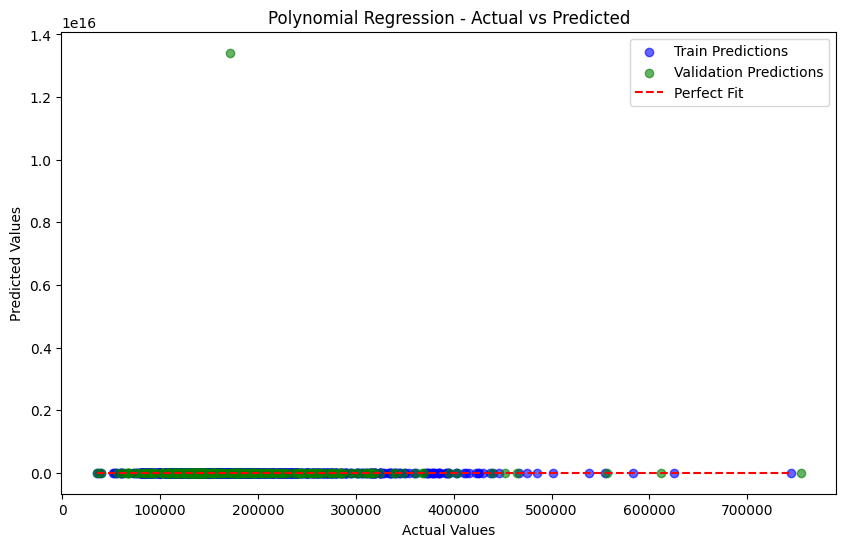

In [468]:
import matplotlib.pyplot as plt

# Polynomial Regression 예측 결과 시각화
plt.figure(figsize=(10, 6))

# Train 데이터 예측값 vs 실제값
plt.scatter(y_train, train_predictions_poly, color='blue', label='Train Predictions', alpha=0.6)

# Validation 데이터 예측값 vs 실제값
plt.scatter(y_valid, valid_predictions_poly, color='green', label='Validation Predictions', alpha=0.6)

# 완벽한 예측선 (y = x)
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red', linestyle='--', label='Perfect Fit')

plt.title('Polynomial Regression - Actual vs Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()
